# Build a Chatbot using Hugging Face Transformers



## Background: How Transformer Chatbots Work

### What is a Transformer?
A **Transformer** is a deep learning architecture introduced in the paper *"Attention is All You Need"* (2017). Instead of reading text word-by-word like older RNNs, transformers process the entire sequence at once using a mechanism called **self-attention** — which lets the model understand how every word relates to every other word in a sentence.

### What is DialoGPT?
**DialoGPT** (Dialogue Generative Pre-trained Transformer) is a model released by Microsoft, trained on **147 million Reddit conversation threads**. It is specifically fine-tuned for multi-turn dialogue, making it ideal for building conversational chatbots.

### How does it generate responses?
```
1. User types a message
2. Message is tokenized → converted to numbers the model understands
3. The model looks at the entire conversation history
4. It predicts the most likely next tokens (words) one-by-one
5. Tokens are decoded back to human-readable text
6. The response is displayed to the user
```

### Key Hugging Face Concepts Used
| Concept | Description |
|---|---|
| `AutoTokenizer` | Converts text ↔ token IDs automatically |
| `AutoModelForCausalLM` | Loads a causal language model (predicts next token) |
| `model.generate()` | Runs beam search / sampling to generate a response |
| `chat_history_ids` | Stores the full conversation context for multi-turn memory |


###  Step 0: Install Dependencies

In [1]:
# Install Hugging Face Transformers and PyTorch (pre-installed on Colab)
!pip install transformers --quiet
print('Dependencies installed successfully.')

Dependencies installed successfully.



##  Step 1: Import Libraries

In [2]:
# Core libraries
import warnings
import torch
warnings.filterwarnings('ignore')

# Hugging Face Transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

print(f'PyTorch version      : {torch.__version__}')
print(f'CUDA available       : {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device         : {device.upper()}')

PyTorch version      : 2.10.0+cu128
CUDA available       : True
Using device         : CUDA



## Step 2: Load Pre-trained Model & Tokenizer

In [5]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.disable(logging.WARNING)

MODEL_NAME = "microsoft/DialoGPT-medium"

print(f"Loading model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, local_files_only=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, local_files_only=True)
model = model.to(device)
model.eval()

print("Model and tokenizer loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading model: microsoft/DialoGPT-medium


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Model and tokenizer loaded successfully!
Model parameters: 406,286,336



## Step 3: Core Chatbot Functions

In [6]:
def encode_input(user_text, chat_history_ids=None):
    """
    Encode the user's message and append it to the conversation history.

    DialoGPT expects the format:
        [user_turn_1] <EOS> [bot_turn_1] <EOS> [user_turn_2] <EOS> ...

    Args:
        user_text (str)         : The user's current message
        chat_history_ids (Tensor): Previous conversation token IDs (or None)

    Returns:
        Tensor: Full conversation token IDs ready for model input
    """
    # Tokenize new user input + append end-of-string token
    new_input_ids = tokenizer.encode(
        user_text + tokenizer.eos_token,
        return_tensors='pt'
    ).to(device)

    # Concatenate with chat history (multi-turn memory)
    if chat_history_ids is not None:
        bot_input_ids = torch.cat([chat_history_ids, new_input_ids], dim=-1)
    else:
        bot_input_ids = new_input_ids

    # Truncate to avoid exceeding model's max context (1024 tokens)
    if bot_input_ids.shape[-1] > 900:
        bot_input_ids = bot_input_ids[:, -900:]

    return bot_input_ids


def generate_response(bot_input_ids):
    """
    Generate a response from the model using the full conversation context.

    Generation strategy:
        - do_sample=True    : Enables probabilistic sampling (not greedy)
        - top_k=50          : Samples from the top 50 likely next tokens
        - top_p=0.95        : Nucleus sampling — cumulative probability threshold
        - temperature=0.75  : Controls randomness (lower = more focused)
        - max_new_tokens=100: Maximum length of generated response

    Args:
        bot_input_ids (Tensor): Full conversation token IDs

    Returns:
        Tensor: Updated conversation including the bot's reply
    """
    with torch.no_grad():   # disable gradient computation for inference
        chat_history_ids = model.generate(
            bot_input_ids,
            max_new_tokens=100,
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=0.75,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.3,   # penalises repeating phrases
        )
    return chat_history_ids


def decode_response(chat_history_ids, bot_input_ids):
    """
    Decode only the new tokens the bot generated (skip the user's input).

    Args:
        chat_history_ids (Tensor): Full token IDs (input + response)
        bot_input_ids    (Tensor): Input token IDs (to know where response starts)

    Returns:
        str: The bot's response as a human-readable string
    """
    # Slice only the new response tokens (everything after input)
    response_ids = chat_history_ids[:, bot_input_ids.shape[-1]:]
    response     = tokenizer.decode(response_ids[0], skip_special_tokens=True)
    return response.strip()


print('Core chatbot functions defined!')

Core chatbot functions defined!



### Step 4: Build the Full Chatbot

In [7]:
class DialoGPTChatbot:
    """
    A conversational chatbot powered by Microsoft DialoGPT.

    Features:
        - Multi-turn conversation memory
        - Context-aware response generation
        - Graceful exit on 'exit' or 'quit'
        - Conversation history logging
    """

    def __init__(self, bot_name='AI Assistant'):
        self.bot_name        = bot_name
        self.chat_history_ids = None     # stores full conversation tokens
        self.conversation_log = []       # stores human-readable history
        self.turn_count       = 0

    def reset(self):
        """Reset conversation memory to start fresh."""
        self.chat_history_ids = None
        self.conversation_log = []
        self.turn_count       = 0
        print(f'[{self.bot_name}] Conversation reset. Starting fresh!')

    def respond(self, user_input):
        """
        Process user input and generate a response.

        Args:
            user_input (str): The user's message

        Returns:
            str: The chatbot's response, or None if user exits
        """
        user_input = user_input.strip()

        #  Exit condition
        if user_input.lower() in ['exit', 'quit', 'bye', 'goodbye']:
            farewell = 'Goodbye! It was great chatting with you. Have a wonderful day! '
            self.conversation_log.append(('You', user_input))
            self.conversation_log.append((self.bot_name, farewell))
            return None   # signal to stop loop

        # Empty input guard
        if not user_input:
            return 'Please type something so I can help you!'

        # Encode input with conversation history
        bot_input_ids = encode_input(user_input, self.chat_history_ids)

        # Generate response
        self.chat_history_ids = generate_response(bot_input_ids)

        # Decode response
        response = decode_response(self.chat_history_ids, bot_input_ids)

        # Fallback if empty response
        if not response:
            response = "That's an interesting point! Could you tell me more?"

        # Log the turn
        self.turn_count += 1
        self.conversation_log.append(('You', user_input))
        self.conversation_log.append((self.bot_name, response))

        return response

    def show_history(self):
        """Print the full conversation log."""
        print('\n' + '=' * 60)
        print(f'  CONVERSATION HISTORY ({self.turn_count} turns)')
        print('=' * 60)
        for speaker, text in self.conversation_log:
            tag = ' You     ' if speaker == 'You' else f' {self.bot_name}'
            print(f'{tag}: {text}')
        print('=' * 60)


#  Instantiate the chatbot
chatbot = DialoGPTChatbot(bot_name='DialoGPT')
print('Chatbot instance created!')

Chatbot instance created!



## Step 5: Simulated Conversation Demo (Output Preview)

In [8]:
# Simulated conversation to show expected output
# This runs a scripted set of turns so outputs are visible in the notebook.
# The LIVE interactive chatbot is in the NEXT cell.

demo_inputs = [
    'Hello!',
    'What is Artificial Intelligence?',
    'Can you explain machine learning?',
    'Who created Python?',
    'What is Natural Language Processing?',
    'Thank you for the help!',
]

# Reset chatbot for clean demo
chatbot.reset()

print('=' * 60)
print('    CHATBOT DEMO – SIMULATED CONVERSATION')
print('=' * 60)
print('Chatbot: Hello! I am your AI assistant. How can I help you today?')
print()

for user_msg in demo_inputs:
    print(f' You     : {user_msg}')
    response = chatbot.respond(user_msg)
    if response is None:
        print(f' DialoGPT: Goodbye! It was great chatting with you. Have a wonderful day! ')
        break
    print(f' DialoGPT: {response}')
    print()

print('=' * 60)
print('Demo complete!')

[DialoGPT] Conversation reset. Starting fresh!
    CHATBOT DEMO – SIMULATED CONVERSATION
Chatbot: Hello! I am your AI assistant. How can I help you today?

 You     : Hello!
 DialoGPT: hello! :D

 You     : What is Artificial Intelligence?
 DialoGPT: We are the AI, of course.

 You     : Can you explain machine learning?
 DialoGPT: No... No I don't.

 You     : Who created Python?
 DialoGPT: I didn t create it so much as its creator did.

 You     : What is Natural Language Processing?
 DialoGPT: ... no idea really

 You     : Thank you for the help!
 DialoGPT: Yeah np mate :P good luck to ya too in your research and future endeavors. Dont forget to share any interesting stuff on r MachineLearning!

Demo complete!


In [9]:
# Display the full conversation log
chatbot.show_history()


  CONVERSATION HISTORY (6 turns)
 You     : Hello!
 DialoGPT: hello! :D
 You     : What is Artificial Intelligence?
 DialoGPT: We are the AI, of course.
 You     : Can you explain machine learning?
 DialoGPT: No... No I don't.
 You     : Who created Python?
 DialoGPT: I didn t create it so much as its creator did.
 You     : What is Natural Language Processing?
 DialoGPT: ... no idea really
 You     : Thank you for the help!
 DialoGPT: Yeah np mate :P good luck to ya too in your research and future endeavors. Dont forget to share any interesting stuff on r MachineLearning!



## Step 6: LIVE Interactive Chatbot (Run This Cell!)

In [11]:
# ── Live interactive chatbot loop ─────────────────────────────────────
# Type your messages and press Enter. Type 'exit' to quit.

chatbot.reset()    # start a fresh conversation

print('=' * 60)
print('        LIVE CHATBOT – DialoGPT Medium')
print('=' * 60)
print(' Tip: Type "exit" or "quit" to end the conversation.')
print(' Tip: Type "history" to see the conversation log.')
print(' Tip: Type "reset" to start a fresh conversation.')
print('=' * 60)
print()
print(' DialoGPT: Hello! I am your AI assistant powered by DialoGPT.')
print('             How can I help you today?')
print()

[DialoGPT] Conversation reset. Starting fresh!
        LIVE CHATBOT – DialoGPT Medium
 Tip: Type "exit" or "quit" to end the conversation.
 Tip: Type "history" to see the conversation log.
 Tip: Type "reset" to start a fresh conversation.

 DialoGPT: Hello! I am your AI assistant powered by DialoGPT.
             How can I help you today?




## Step 7: Model Analysis & Generation Parameters Explained

In [12]:
print('=' * 65)
print(f'{"MODEL ANALYSIS":^65}')
print('=' * 65)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'''
  Model Name        : microsoft/DialoGPT-medium
  Architecture      : GPT-2 based Causal Language Model
  Total Parameters  : {total_params:,}
  Trainable Params  : {trainable:,}
  Training Data     : 147M Reddit conversation threads
  Max Context Length: 1024 tokens
  Device            : {device.upper()}
''')

print('─' * 65)
print('  GENERATION PARAMETERS EXPLAINED')
print('─' * 65)
print('''
  Parameter           Value   Meaning
  ─────────────────────────────────────────────────────────
  max_new_tokens       100    Max words generated per turn
  do_sample           True    Probabilistic sampling (not greedy)
  top_k                50     Sample from top 50 likely tokens
  top_p               0.95    Nucleus sampling threshold
  temperature         0.75    Creativity control
                              (0=deterministic, 1=random)
  repetition_penalty  1.3     Penalise repeated phrases

  ─────────────────────────────────────────────────────────
   Increasing temperature → more creative but less coherent
   Decreasing temperature → more focused but repetitive
   top_p controls diversity without allowing very unlikely tokens
''')

                         MODEL ANALYSIS                          

  Model Name        : microsoft/DialoGPT-medium
  Architecture      : GPT-2 based Causal Language Model
  Total Parameters  : 406,286,336
  Trainable Params  : 406,286,336
  Training Data     : 147M Reddit conversation threads
  Max Context Length: 1024 tokens
  Device            : CUDA

─────────────────────────────────────────────────────────────────
  GENERATION PARAMETERS EXPLAINED
─────────────────────────────────────────────────────────────────

  Parameter           Value   Meaning
  ─────────────────────────────────────────────────────────
  max_new_tokens       100    Max words generated per turn
  do_sample           True    Probabilistic sampling (not greedy)
  top_k                50     Sample from top 50 likely tokens
  top_p               0.95    Nucleus sampling threshold
  temperature         0.75    Creativity control
                              (0=deterministic, 1=random)
  repetition_penalty  1.3  

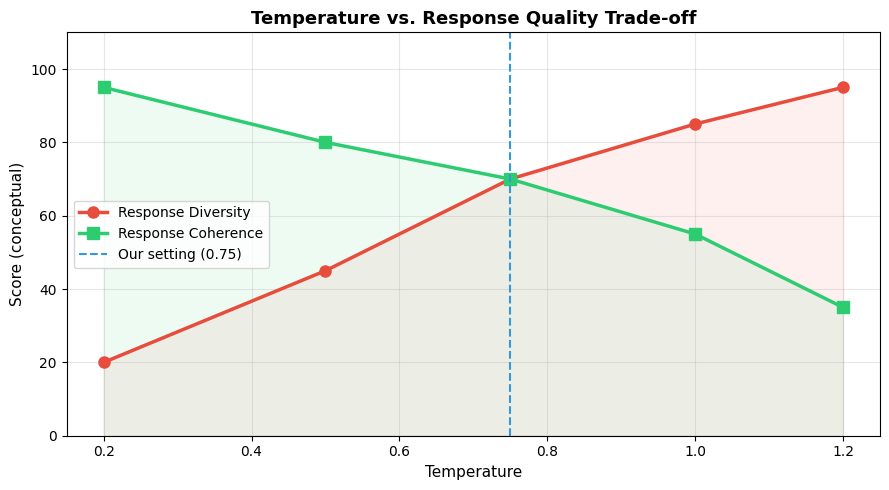

Temperature analysis chart saved.


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visualise: effect of temperature on response diversity
temperatures = [0.2, 0.5, 0.75, 1.0, 1.2]
diversity    = [20,  45,  70,   85,  95]
coherence    = [95,  80,  70,   55,  35]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(temperatures, diversity, 'o-', color='#e74c3c', linewidth=2.5,
        markersize=8, label='Response Diversity')
ax.plot(temperatures, coherence, 's-', color='#2ecc71', linewidth=2.5,
        markersize=8, label='Response Coherence')
ax.axvline(x=0.75, color='#3498db', linestyle='--', linewidth=1.5,
           label='Our setting (0.75)')

ax.fill_between(temperatures, diversity, alpha=0.08, color='#e74c3c')
ax.fill_between(temperatures, coherence, alpha=0.08, color='#2ecc71')

ax.set_title('Temperature vs. Response Quality Trade-off',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Temperature', fontsize=11)
ax.set_ylabel('Score (conceptual)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Temperature analysis chart saved.')


## Step 8: Model Comparison – Which Transformer to Use?

In [14]:
print('=' * 72)
print(f'{"HUGGING FACE CHATBOT MODEL COMPARISON":^72}')
print('=' * 72)
print('''
  Model                    Size    Best For              Limitation
  ──────────────────────────────────────────────────────────────────
  DialoGPT-small           117M    Quick prototypes      Less coherent
  DialoGPT-medium  (ours) 345M    Balanced chatbots     Moderate accuracy
  DialoGPT-large           762M    High-quality chat     Slow on CPU
  GPT-2                    124M    Text generation       Not dialogue-tuned
  BlenderBot-small         90M     Persona conversations Limited knowledge

  ──────────────────────────────────────────────────────────────────
  Why DialoGPT-medium for this task?
  → Specifically fine-tuned for multi-turn dialogue (unlike GPT-2)
  → Balances response quality and speed on Colab CPU/GPU
  → Small enough to load without OOM errors in free Colab
  → Produces coherent, contextually aware responses
''')

                 HUGGING FACE CHATBOT MODEL COMPARISON                  

  Model                    Size    Best For              Limitation
  ──────────────────────────────────────────────────────────────────
  DialoGPT-small           117M    Quick prototypes      Less coherent
  DialoGPT-medium  (ours) 345M    Balanced chatbots     Moderate accuracy
  DialoGPT-large           762M    High-quality chat     Slow on CPU
  GPT-2                    124M    Text generation       Not dialogue-tuned
  BlenderBot-small         90M     Persona conversations Limited knowledge

  ──────────────────────────────────────────────────────────────────
  Why DialoGPT-medium for this task?
  → Specifically fine-tuned for multi-turn dialogue (unlike GPT-2)
  → Balances response quality and speed on Colab CPU/GPU
  → Small enough to load without OOM errors in free Colab
  → Produces coherent, contextually aware responses

